# Machine Learning (Diabetes Case)
----
JhonDoe

## Business Requirement & Problem Definition

---

## 1. Background
Rumah sakit dan klinik sering menghadapi tantangan dalam melakukan deteksi dini diabetes pada pasien.
Proses identifikasi risiko biasanya masih bergantung pada pemeriksaan manual dan interpretasi dokter terhadap hasil medis pasien.

Akibatnya:

Risiko diabetes kadang terlambat terdeteksi
Pasien berisiko tinggi tidak segera mendapatkan tindakan preventif
Beban pemeriksaan tenaga medis menjadi lebih besar
Pengambilan keputusan bisa berbeda antar tenaga kesehatan

Dataset Pima Indians Diabetes berisi data medis pasien perempuan keturunan Pima Indian yang digunakan untuk memprediksi kemungkinan seseorang mengalami diabetes berdasarkan kondisi kesehatannya.

Dengan pendekatan Machine Learning, sistem dapat membantu tenaga medis dalam melakukan screening awal risiko diabetes secara lebih cepat dan konsisten.
---

## 2. Business Objective
- Membantu tenaga medis melakukan deteksi dini diabetes
- Mengidentifikasi pasien dengan risiko tinggi secara lebih cepat
- Mendukung proses pengambilan keputusan medis berbasis data
- Mengurangi risiko keterlambatan penanganan pasien

Model digunakan sebagai decision support system, bukan pengganti diagnosis dokter.

---

## 3. Problem Definition

### Business Question
Apakah seorang pasien memiliki kemungkinan terkena diabetes berdasarkan data kondisi kesehatannya?

- Machine Learning Framing
- Problem Type: Supervised Learning
- Task: Binary Classification
- Target Variable: Outcome
  - 1 → Positif diabetes
  - 0 → Negatif diabetes

Model menghasilkan probabilitas risiko diabetes yang dapat digunakan sebagai dasar screening awal pasien.

---

## 4. Input Data

---
### Numerical Features
---
#### Pregnancies
- Jumlah kehamilan yang pernah dialami pasien.
#### Glucose
- Kadar glukosa dalam darah setelah tes oral glucose tolerance.
#### BloodPressure
- Tekanan darah diastolik pasien.
#### SkinThickness
- Ketebalan lipatan kulit tricep yang digunakan sebagai indikator lemak tubuh.
#### Insulin
- Kadar insulin dalam darah pasien.
#### BMI
- Body Mass Index, yaitu rasio berat badan terhadap tinggi badan untuk mengukur tingkat obesitas.
#### DiabetesPedigreeFunction
- Nilai yang merepresentasikan riwayat keturunan diabetes dalam keluarga.
#### Age
- Umur pasien.

---
### Categorical Features
---
NO Categorical feature
---

---
### Target Variable
---
Outcome
Status diabetes pasien:

- 1 = Mengidap diabetes
- 0 = Tidak mengidap diabetes

  



# 1. Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [2]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# 2. Preprocessing Data
---
Melakukan preprocessing sebelum mengolah data yang akan digunakan :

### 1. Cek apakah ada data duplikasi
Jika ada duplikasi data tangani dengan cara menghilangkan duplikasi data dan tetap mempertahankan data yang pertama (1)
### 2. Cek apakah ada data yang bernilai nol mencurigakan ?
disini saya menemukan bahwa ada beberapa data yang bernilai 0 mencurigakan kemungkinan ini untuk mengganti nilai yang hilang contohnya (glucose, BloodPressure,SkinThickness,Insulin,danBMI) ini menyebabkan prediksi akan palsu.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [8]:
df.duplicated().sum()

np.int64(0)

In [4]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [6]:
df.dtypes

,0
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


In [7]:
(df==0).sum()

,0
Pregnancies,111
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,500


In [10]:
invalid_columns = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

for col in invalid_columns:
    print(f"{col} : {(df[col] == 0).sum()}")

Glucose : 5
BloodPressure : 35
SkinThickness : 227
Insulin : 374
BMI : 11


Disini terlihat beberapa kolom numerik yang mencurigakan bernilai 0

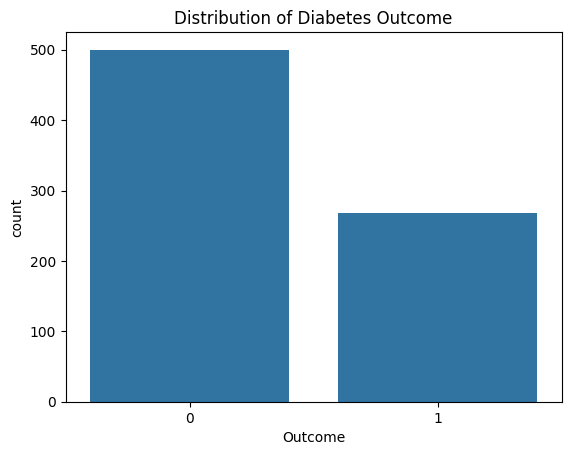

In [14]:
sns.countplot(x='Outcome', data=df)

plt.title("Distribution of Diabetes Outcome")
plt.show()


In [15]:
df['Outcome'].value_counts(normalize=True) * 100

,proportion
Outcome,
0,65.104167
1,34.895833


Disini Terlihat bahwa Class Imbalance (jadi kita tidak boleh hanya menggunakan akurasi)

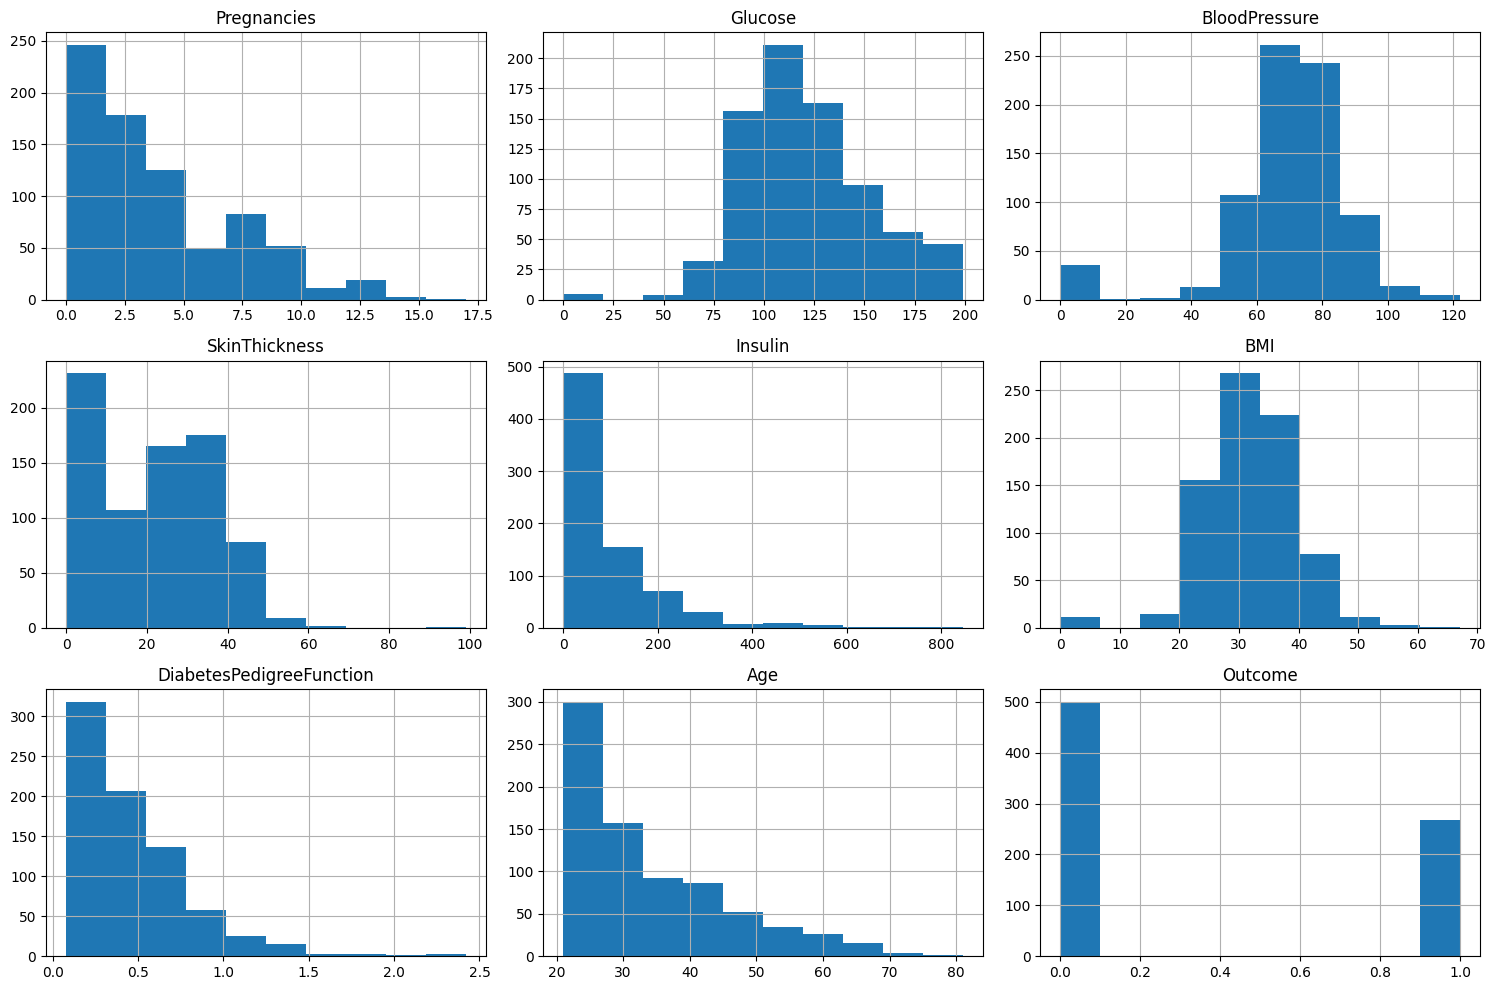

In [13]:
df.hist(figsize=(15,10))

plt.tight_layout()
plt.show()

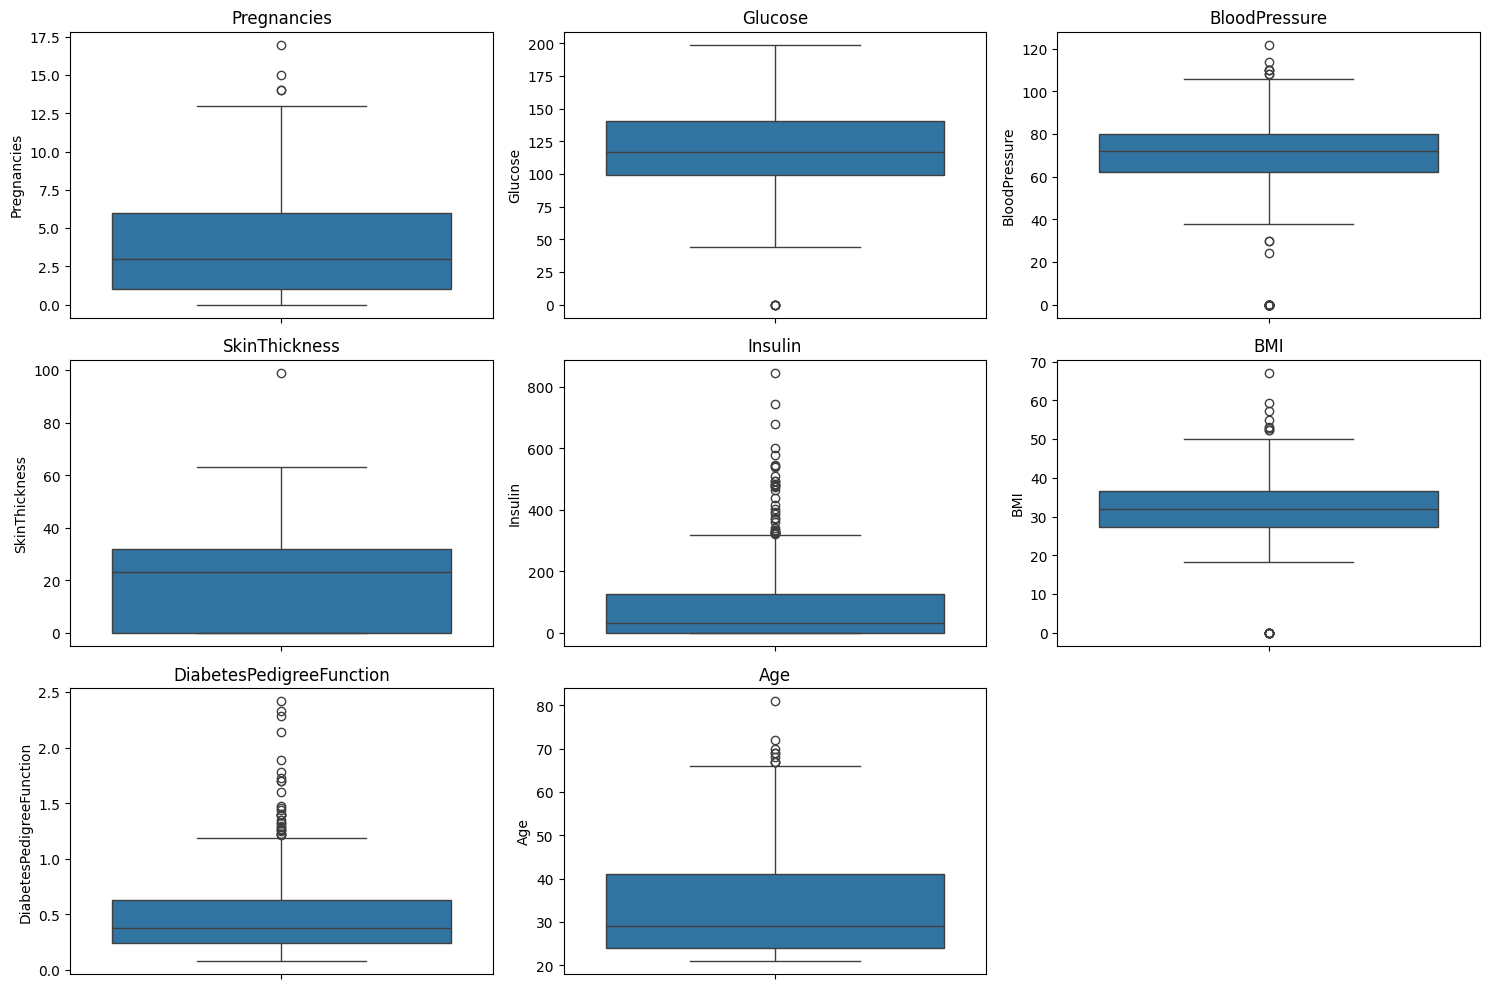

In [16]:
plt.figure(figsize=(15,10))

for i, col in enumerate(df.columns[:-1], 1):
    plt.subplot(3,3,i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Darisini terlihat sedikit ada beberapa outlier contohnya Insulin (800)

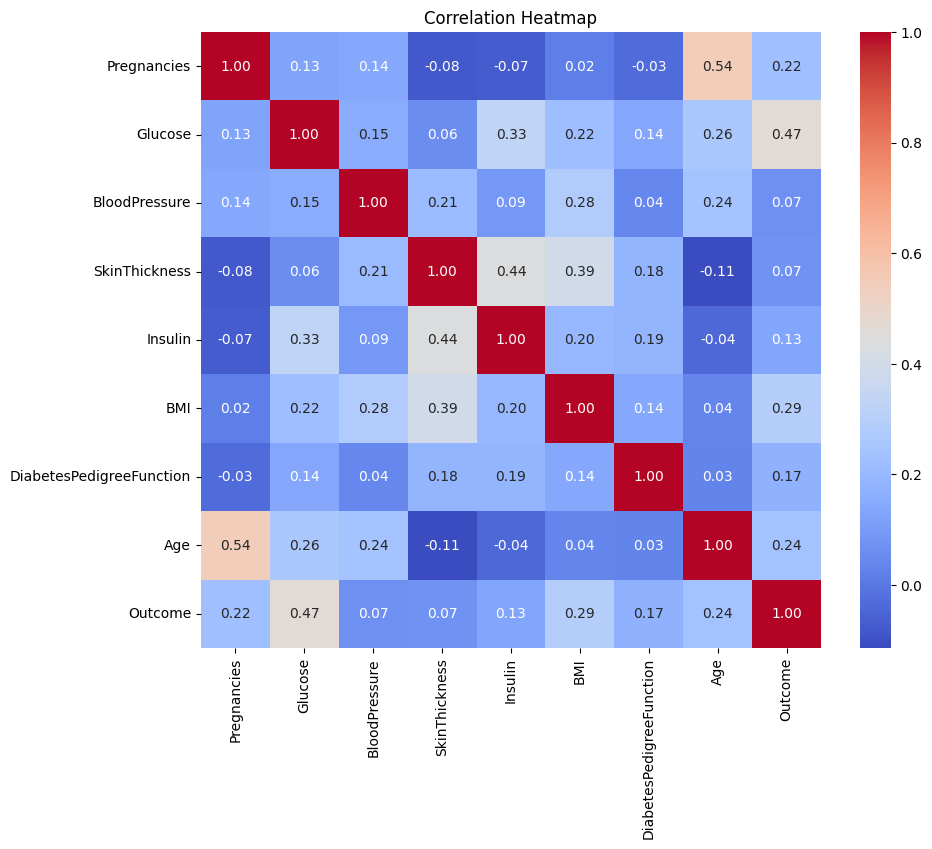

In [17]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

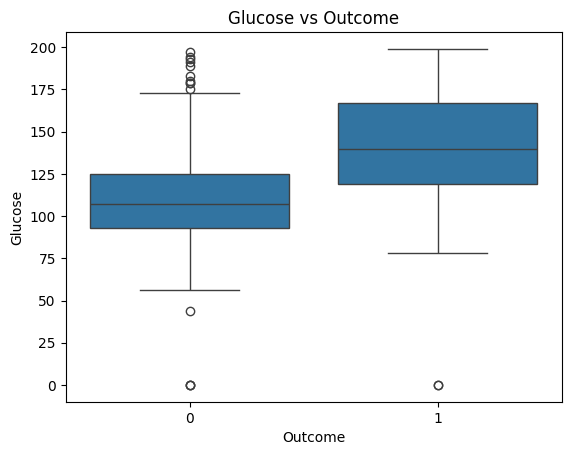

In [18]:
sns.boxplot(x='Outcome', y='Glucose', data=df)

plt.title("Glucose vs Outcome")
plt.show()

# Data Cleaning & Ingeestion

In [19]:
df_clean = df.copy()

In [20]:
invalid_zero_columns = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

Menentukan Nilai nol yang bermasalah (tidak Valid)

In [21]:
df_clean[invalid_zero_columns] = df_clean[invalid_zero_columns].replace(0, np.nan)

In [22]:
df_clean.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [24]:
missing_percentage = (
    df_clean.isnull().sum() / len(df_clean)
) * 100

missing_percentage.sort_values(ascending=False)

,0
Insulin,48.697917
SkinThickness,29.557292
BloodPressure,4.557292
BMI,1.432292
Glucose,0.651042
Pregnancies,0.000000
DiabetesPedigreeFunction,0.000000
Age,0.000000
Outcome,0.000000


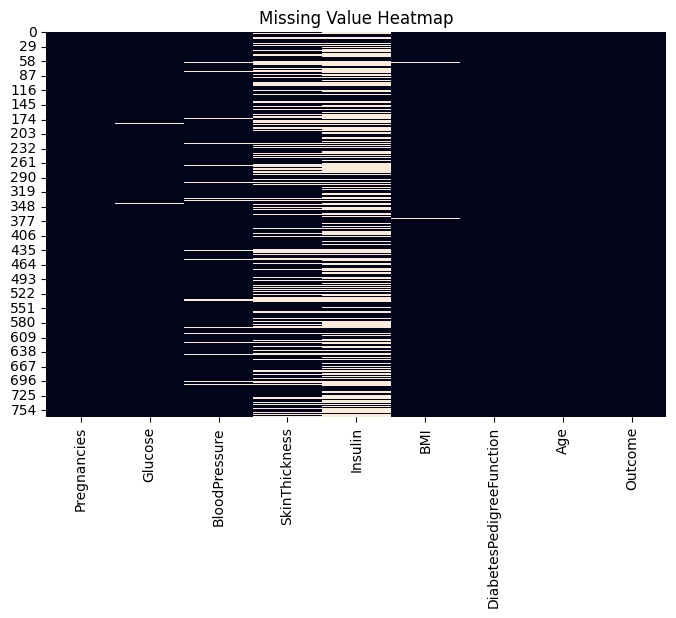

In [25]:
plt.figure(figsize=(8,5))

sns.heatmap(df_clean.isnull(), cbar=False)

plt.title("Missing Value Heatmap")
plt.show()

# Data PreProcessing / Feature Engineering

In [26]:
X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

X adalah Petunjuk pasien Sedangkan Y adalah Diagnosis Akhir

In [28]:
from sklearn.model_selection import train_test_split
# Kita menggunakan Stratify karena data kita sangat imbalance jika tadi dilihat
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [29]:
# Cek bentuk data
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(614, 8)
(154, 8)
(614,)
(154,)


In [30]:
# Distribusi Data Setelah Split
print(y_train.value_counts(normalize=True))
print()

print(y_test.value_counts(normalize=True))

Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


# EDA after Split


In [31]:
# Cek Mising X_train
X_train.isnull().sum()


,0
Pregnancies,0
Glucose,4
BloodPressure,23
SkinThickness,175
Insulin,290
BMI,9
DiabetesPedigreeFunction,0
Age,0


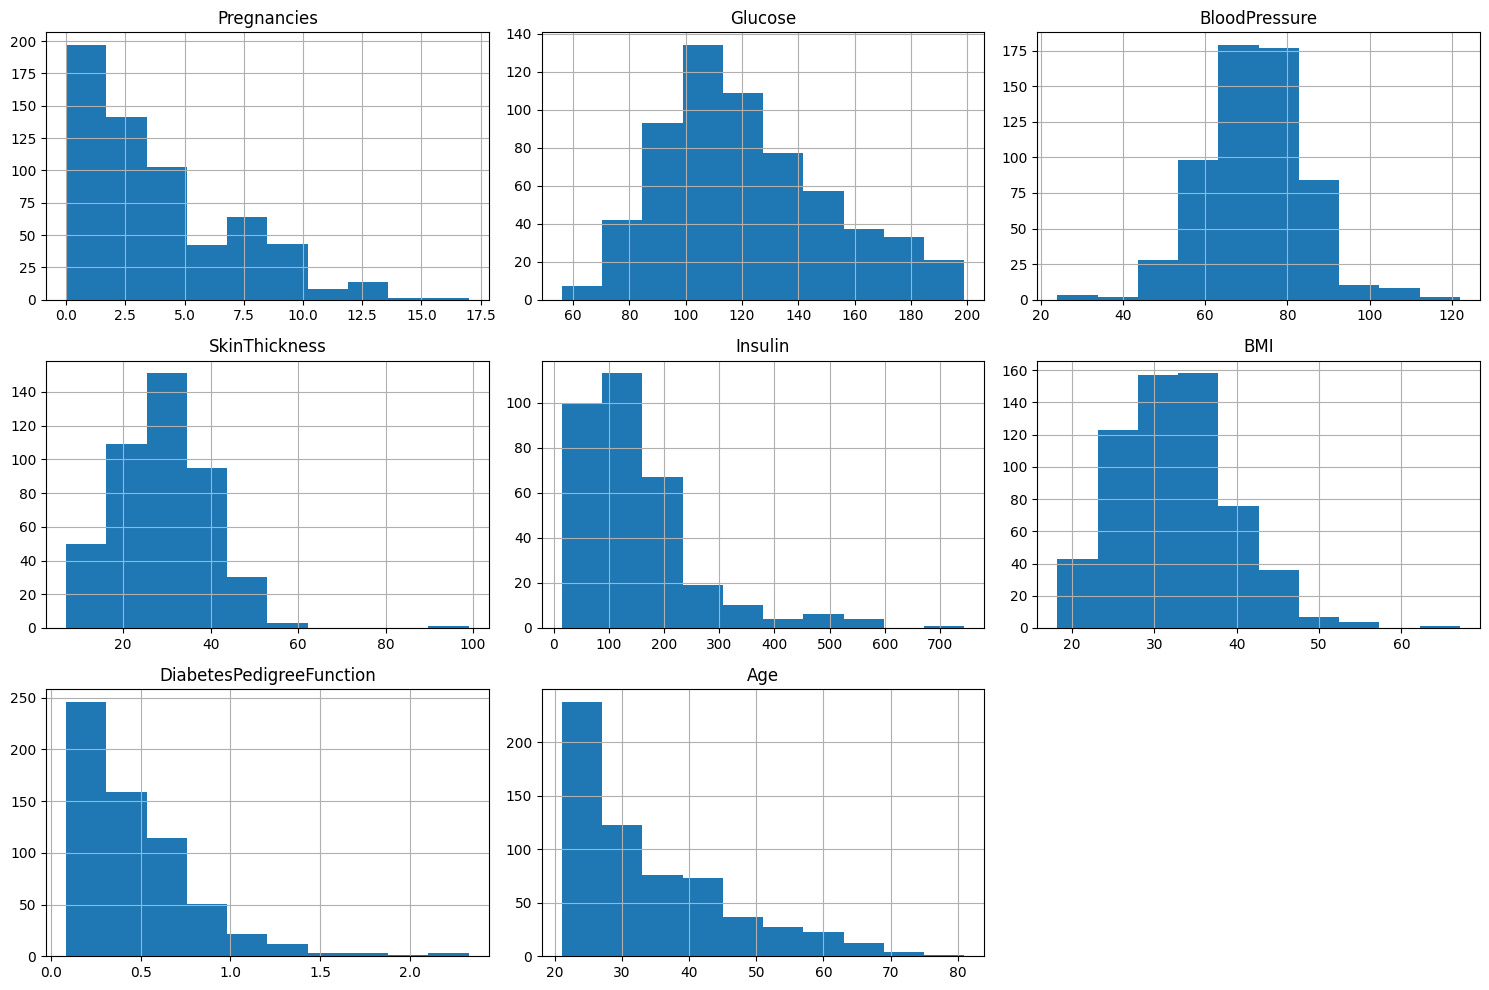

In [32]:
# Cek Distribusi Train
X_train.hist(figsize=(15,10))

plt.tight_layout()
plt.show()

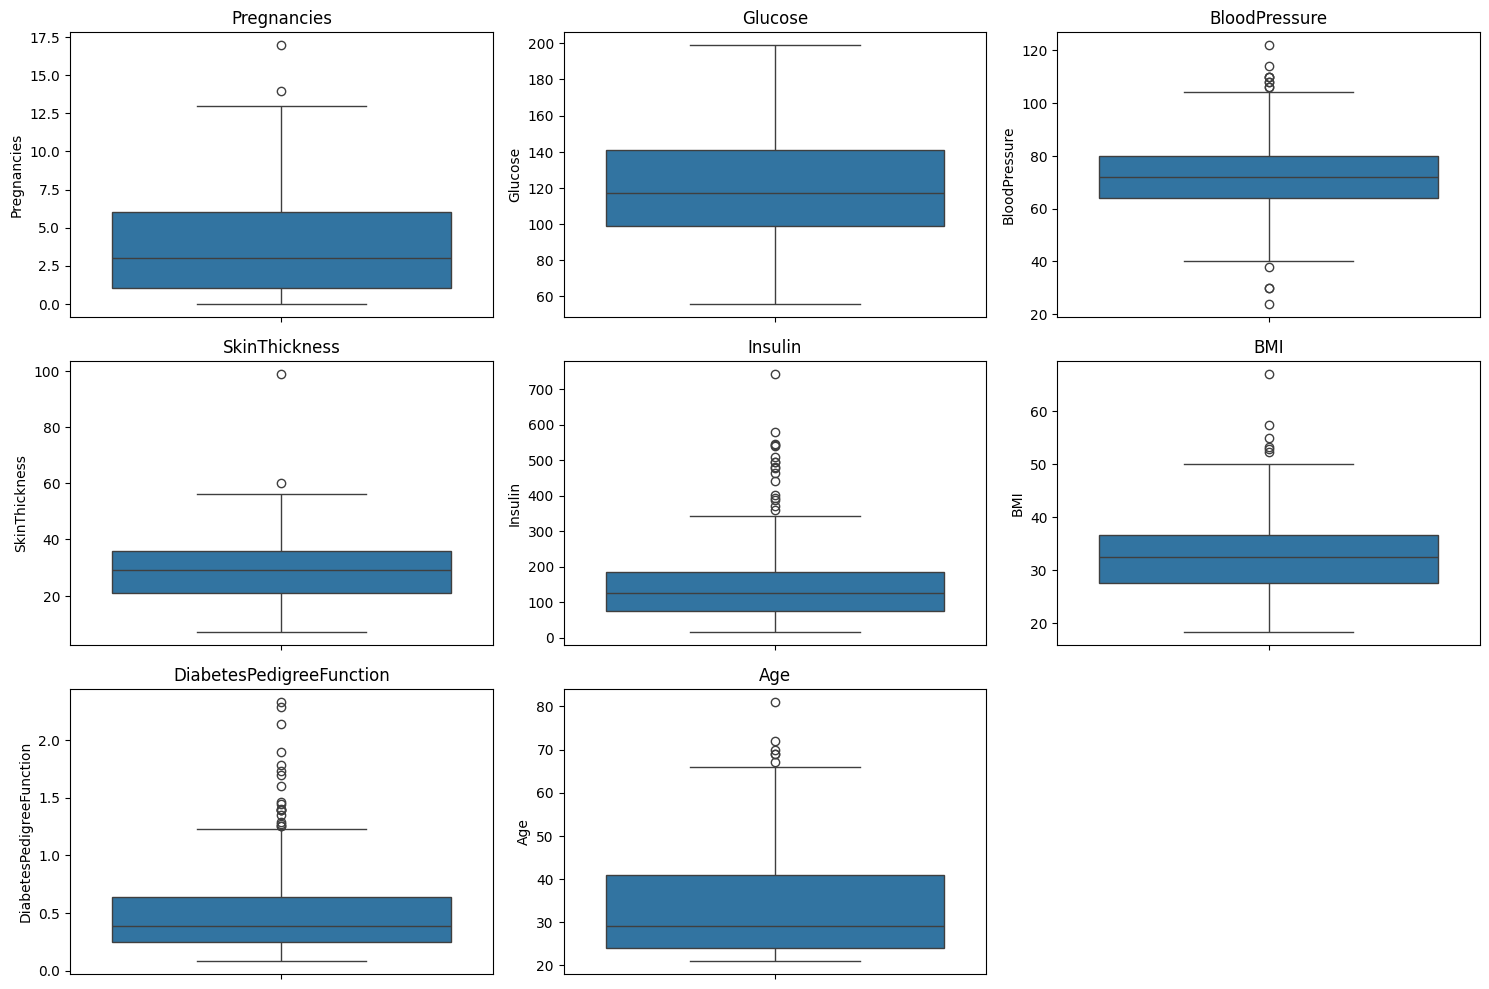

In [33]:
# Outlier Train Set
plt.figure(figsize=(15,10))

for i, col in enumerate(X_train.columns, 1):
    plt.subplot(3,3,i)
    sns.boxplot(y=X_train[col])
    plt.title(col)

plt.tight_layout()
plt.show()

# Pre Processing after Split


In [34]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [36]:
# Imputer
imputer = SimpleImputer(strategy='median')

In [40]:
# Fit TO Train
X_train_imputed = imputer.fit_transform(X_train)

# Transform to Test
X_test_imputed = imputer.transform(X_test)


In [41]:
# Kembalikan Ke data frame
X_train_imputed = pd.DataFrame(
    X_train_imputed,
    columns=X_train.columns
)

X_test_imputed = pd.DataFrame(
    X_test_imputed,
    columns=X_test.columns
)

In [43]:
# Cek apakah Missing value Hilang (Harus)
X_train_imputed.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0


In [44]:
# Scaling
scaler = StandardScaler()

In [46]:
# Fit Train
X_train_scaled = scaler.fit_transform(X_train_imputed)

#Transform Test
X_test_scaled = scaler.transform(X_test_imputed)

In [47]:
# Cek Hasil Scaling
pd.DataFrame(X_train_scaled, columns=X_train.columns).describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,6.140000e+02,6.140000e+02,6.140000e+02,6.140000e+02,6.140000e+02,6.140000e+02,6.140000e+02,6.140000e+02
mean,-6.943414e-17,-1.099374e-16,3.095606e-16,-3.471707e-17,-4.339634e-18,1.649061e-16,-1.099374e-16,-1.084908e-16
std,1.000815e+00,1.000815e+00,1.000815e+00,1.000815e+00,1.000815e+00,1.000815e+00,1.000815e+00,1.000815e+00
min,-1.153338e+00,-2.190541e+00,-3.924957e+00,-2.480958e+00,-1.559139e+00,-2.089621e+00,-1.192094e+00,-1.045895e+00
25%,-8.513551e-01,-7.562208e-01,-6.636760e-01,-4.549828e-01,-2.249692e-01,-7.073644e-01,-7.042617e-01,-7.921693e-01
50%,-2.473897e-01,-1.558076e-01,-1.141979e-02,-4.766137e-03,-1.614373e-01,-7.070181e-03,-2.876344e-01,-3.692933e-01
75%,6.585583e-01,6.113872e-01,6.408364e-01,3.328964e-01,-9.790537e-02,5.942296e-01,4.903223e-01,6.456090e-01
max,3.980368e+00,2.579408e+00,4.065181e+00,7.874025e+00,7.703814e+00,5.081979e+00,5.610293e+00,4.028617e+00


In [50]:
# Cek hasil Scaling X_Test
pd.DataFrame(X_test_scaled).head()

,0,1,2,3,4,5,6,7
0,0.960541,1.245157,-0.663676,-0.004766,-0.161437,-0.740363,-0.555791,0.561034
1,1.866489,-1.790266,2.760669,-0.680091,-1.127122,0.447571,-0.583061,1.153060
2,-0.549372,0.010974,0.314708,-0.229874,0.791541,0.506235,0.016882,-0.623019
3,0.960541,-0.255876,-0.663676,-0.004766,-0.161437,-0.740363,0.771356,0.053583
4,-0.549372,-1.590128,-0.011420,-0.004766,-0.161437,-0.007070,-1.137554,-0.961320


In [51]:
# Cek hasil scaling X_Train
pd.DataFrame(X_train_scaled).head()

,0,1,2,3,4,5,6,7
0,-0.851355,-1.056427,-0.826740,-1.918187,-1.203361,-0.769694,0.310794,-0.792169
1,0.356576,0.144399,0.477772,-0.229874,-1.470195,-0.417714,-0.116439,0.561034
2,-0.549372,-0.556083,-1.152868,1.233330,-0.555335,0.359576,-0.764862,-0.707594
3,-0.851355,0.811525,-1.315932,-0.004766,-0.161437,-0.403048,0.262314,-0.369293
4,-1.153338,-0.889646,-0.663676,1.120776,-0.415565,1.782163,-0.337630,-0.961320


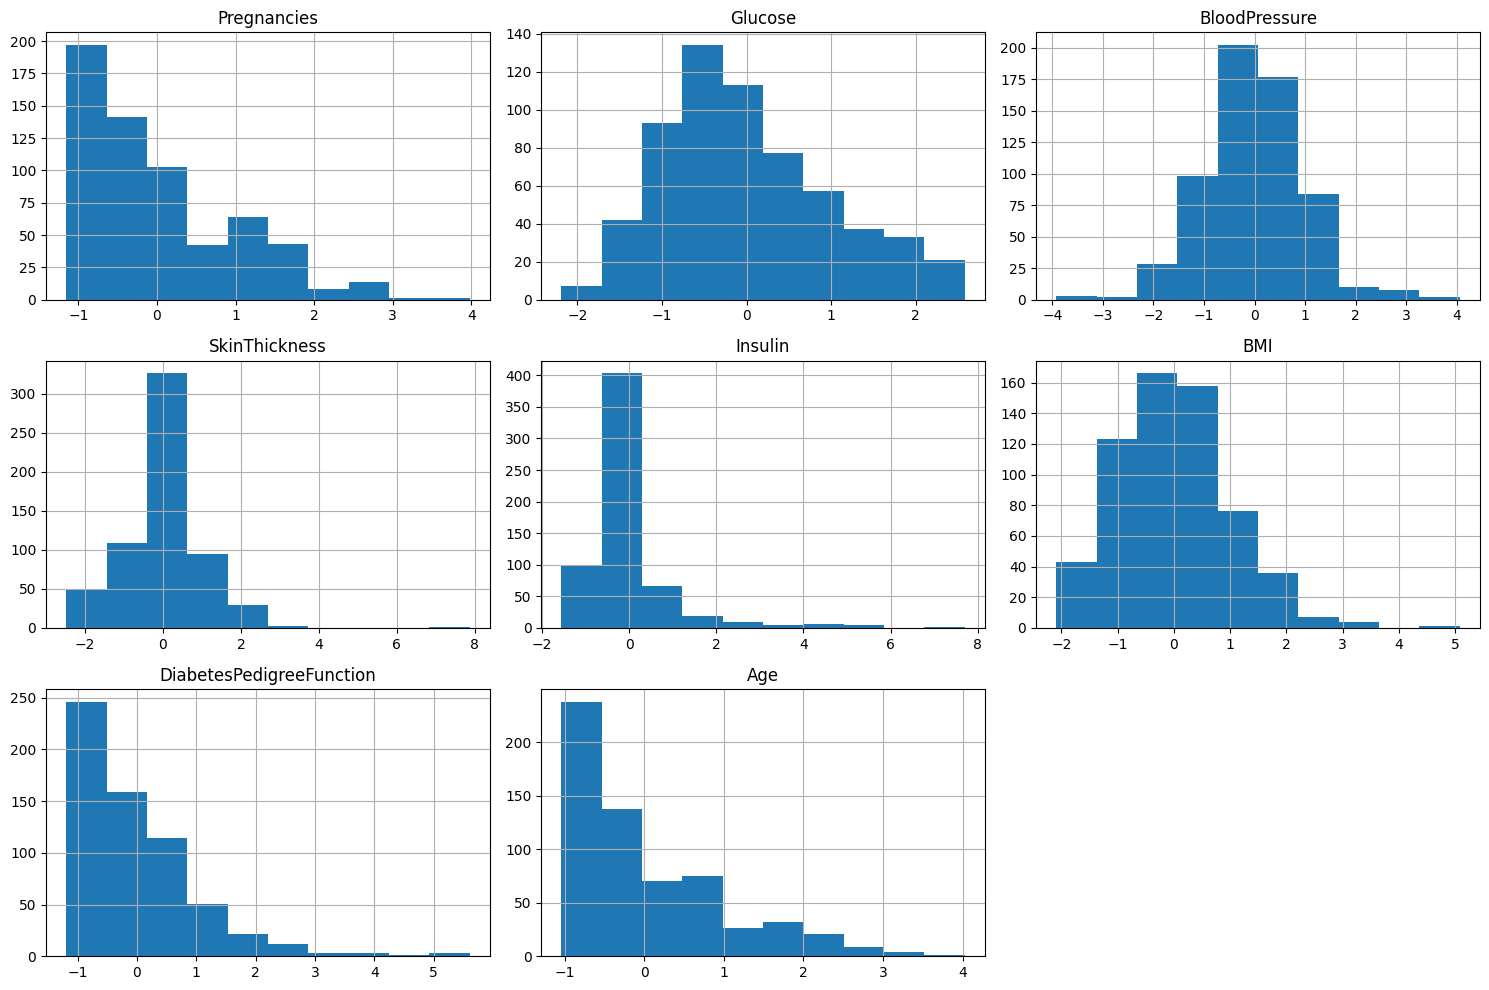

In [54]:
# Cek Distribusi Setelah Scaling Target
scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

scaled_df.hist(figsize=(15,10))

plt.tight_layout()
plt.show()

In [55]:
print("X_train_scaled shape :", X_train_scaled.shape)
print("X_test_scaled shape  :", X_test_scaled.shape)

X_train_scaled shape : (614, 8)
X_test_scaled shape  : (154, 8)


# Modeling

In [59]:
from sklearn.linear_model import LogisticRegression

In [60]:
logreg = LogisticRegression()

In [61]:
logreg.fit(X_train_scaled, y_train)

LogisticRegression()

In [62]:
y_pred = logreg.predict(X_test_scaled)

y_prob = logreg.predict_proba(X_test_scaled)

print(y_prob[:5])

[[0.39030002 0.60969998]
 [0.88170855 0.11829145]
 [0.70657435 0.29342565]
 [0.74919948 0.25080052]
 [0.96647304 0.03352696]]


# Model Evaluations

In [63]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.7077922077922078


In [64]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



In [65]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[82 18]
 [27 27]]


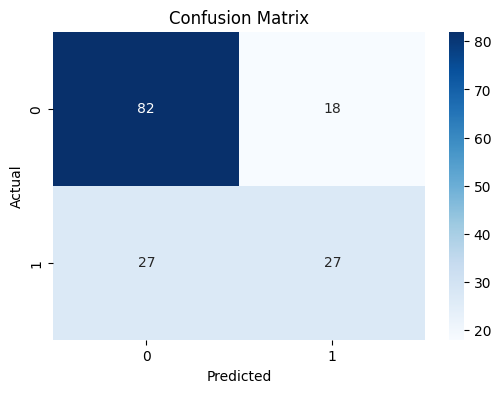

In [66]:
# Visualisasi
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [67]:
# ROC-AUC
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_prob[:,1])

print("ROC-AUC :", auc)

ROC-AUC : 0.812962962962963


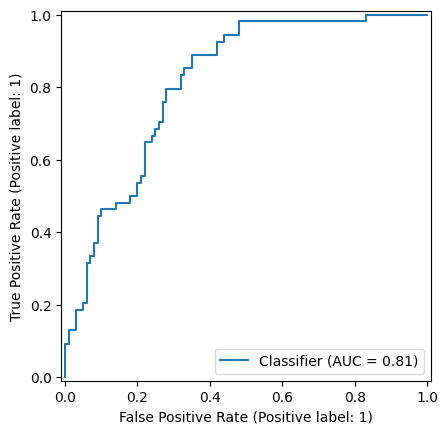

In [68]:
# Curve
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_prob[:,1]
)

plt.show()